# Adaptive conformal under distribution shift

A conformal prediction interval is only as good as the calibration residuals it is
built from. The ordinary recipe takes a fixed set of calibration scores, reads off a
quantile, and reuses that quantile forever. That works when the future looks like
the calibration set. It fails silently when the process drifts: a level break, a
variance jump, or volatility clustering all make the old quantile the wrong width, and
the interval quietly mis-covers.

Three approaches let the calibration follow the data, and `tsbootstrap` ships
two of them in `tsbootstrap.uq.adaptive`:

1. **Reweight the calibration data toward recent scores.** This is Nonexchangeable
   Conformal Prediction (NexCP, Barber et al. 2023), exposed as `nexcp_quantile`. A
   decay factor down-weights old residuals so recent behaviour dominates the quantile.
2. **Refresh the residuals as you go.** Sliding-window EnbPI re-estimates the
   nonconformity scores from a moving window of recent out-of-bag errors. The EnbPI
   layer covered in the forecast-intervals tutorial does this job, so we do not repeat
   it here.
3. **Adapt the target level online.** This is Adaptive Conformal Inference (ACI,
   Gibbs and Candes 2021), exposed as `aci_halfwidths`. It nudges the miscoverage
   level up or down at every step from the realized hits and misses, so long-run
   coverage tracks the target even when the score distribution moves arbitrarily.

### What each method actually guarantees

The two methods buy different things, and the fine print matters:

- **ACI** gives a long-run, time-averaged coverage guarantee that is robust to
  arbitrary distribution shift. It does not promise conditional coverage, so the interval
  at any single step can be wrong, and the learning rate `gamma` is a knob: too small
  and it reacts slowly to a shock, too large and the level jitters. The guarantee
  covers the average over time, not any one prediction.
- **NexCP** keeps a finite-sample coverage guarantee, but minus a gap that grows with
  how much the data actually drifted. Under exchangeability the gap is zero and you
  recover ordinary conformal; under drift you trade a small, quantifiable coverage gap
  for intervals that follow the recent regime.

In [1]:
# On Colab or Binder, install tsbootstrap first (skipped if already present):
try:
    import tsbootstrap  # noqa: F401
except ImportError:
    %pip install -q "tsbootstrap[examples]"

## The two functions

Both live in `tsbootstrap.uq.adaptive` and operate on **nonconformity scores**,
typically absolute residuals `|y_t - prediction_t|`. They are deliberately small and
composable: you feed them scores, they hand back interval geometry.

- `aci_halfwidths(calibration_scores, test_scores, *, alpha=0.1, gamma=0.05)` walks the
  test sequence in time order and returns `(halfwidths, alphas)`: the interval
  half-width `q_t` to use at each step and the adapted miscoverage level `alpha_t`.
  The update is `alpha_{t+1} = alpha_t + gamma * (alpha - err_t)`, where `err_t = 1`
  when step `t` is a miss. A miss shrinks the level and widens the next interval.
- `nexcp_quantile(scores, *, alpha=0.1, decay=0.99)` returns a single recency-weighted
  quantile. Score `i` (0 = oldest) gets weight `decay ** (n - 1 - i)`. With `decay = 1`
  this is the ordinary empirical quantile; smaller `decay` leans on recent residuals.

We keep `alpha = 0.1` throughout, so the target coverage is `1 - alpha = 0.90`.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from tsbootstrap.uq.adaptive import aci_halfwidths, nexcp_quantile

ALPHA = 0.1
NOMINAL = 1.0 - ALPHA  # target coverage 0.90
print("target coverage 1 - alpha =", NOMINAL)

target coverage 1 - alpha = 0.9


## ACI on the Nile, with a deliberately stale forecast

The annual flow volume of the Nile at Aswan has a famous structural break around 1898,
the year the first Aswan dam construction began: the mean level drops sharply. This is
the textbook distribution shift, and it is bundled with statsmodels, so it costs us
nothing to load.

To make the point cleanly we use a forecaster that is trained once on the pre-break
regime and then frozen: the constant predictor equal to the pre-1898 mean. This is the
worst case for a static interval. The point forecast never updates, so after the
break both the prediction and any interval calibrated on pre-break residuals are wrong.
Adaptive conformal exists for exactly this situation.

In [3]:
import statsmodels.api as sm

nile = sm.datasets.nile.load_pandas().data
year = nile["year"].to_numpy(dtype=int)
flow = nile["volume"].to_numpy(dtype=float)
n = flow.size

break_idx = int(np.argmin(np.abs(year - 1898)))  # the 1898 structural break
print("series length", n, "| break at index", break_idx, "(year 1898)")

# Frozen forecaster: the pre-break mean, never updated.
pre_break_mean = flow[:break_idx].mean()
prediction = np.full(n, pre_break_mean)
scores = np.abs(flow - prediction)  # nonconformity scores |y_t - prediction_t|

# Calibration = pre-break scores; test = everything from the break onward, in time order.
cal_scores = scores[:break_idx]
test_scores = scores[break_idx:]
test_year = year[break_idx:]
print("calibration size", cal_scores.size, "| test size", test_scores.size)

series length 100 | break at index 27 (year 1898)
calibration size 27 | test size 73


### The static interval mis-covers across the break

First the baseline. A static conformal interval reads one quantile off the calibration
scores and uses it forever. We compute its empirical coverage on the test sequence,
and split that coverage before and after the break to see where it fails.

In [4]:
static_halfwidth = float(np.quantile(cal_scores, 1.0 - ALPHA))
static_covered = (test_scores <= static_halfwidth).astype(float)

static_cov_overall = static_covered.mean()
print(f"static half-width q = {static_halfwidth:.1f}")
print(f"static coverage over the test span: {static_cov_overall:.3f}  (target {NOMINAL:.2f})")

static half-width q = 206.5
static coverage over the test span: 0.342  (target 0.90)


### ACI re-calibrates online and recovers nominal coverage

Now feed the same calibration and test scores to `aci_halfwidths`. It returns a
half-width per step and the adapted level `alpha_t`. A learning rate `gamma = 0.05` is
a reasonable default for a series this short.

In [5]:
aci_hw, aci_alpha = aci_halfwidths(cal_scores, test_scores, alpha=ALPHA, gamma=0.05)
aci_covered = (test_scores <= aci_hw).astype(float)
print(f"ACI coverage over the test span: {aci_covered.mean():.3f}  (target {NOMINAL:.2f})")
print(f"static coverage:                 {static_cov_overall:.3f}")

ACI coverage over the test span: 0.863  (target 0.90)
static coverage:                 0.342


### Rolling coverage: static dips, ACI tracks

A single coverage number hides the dynamics. A rolling-window coverage rate over the
test sequence shows them. The static interval dips below nominal exactly where the
regime moves; the ACI interval climbs back toward the dashed target line as it relearns
the level.

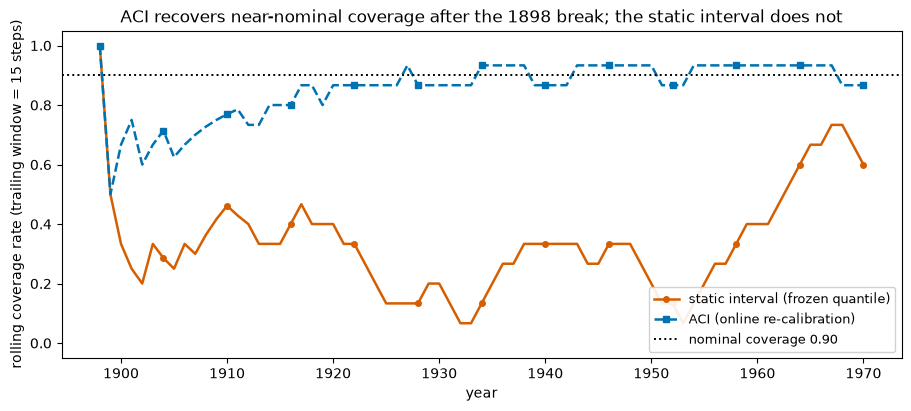

In [6]:
def rolling_mean(hits, window):
    """Trailing rolling mean of a 0/1 hit sequence (expanding until the window fills)."""
    out = np.empty(hits.size)
    for t in range(hits.size):
        lo = max(0, t - window + 1)
        out[t] = hits[lo : t + 1].mean()
    return out


ROLL = 15
static_roll = rolling_mean(static_covered, ROLL)
aci_roll = rolling_mean(aci_covered, ROLL)

# Colorblind-safe palette (Wong 2011): orange for static, blue for ACI.
C_STATIC, C_ACI = "#D55E00", "#0072B2"

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.plot(
    test_year,
    static_roll,
    color=C_STATIC,
    lw=1.8,
    ls="-",
    marker="o",
    markevery=6,
    ms=4,
    label="static interval (frozen quantile)",
)
ax.plot(
    test_year,
    aci_roll,
    color=C_ACI,
    lw=1.8,
    ls="--",
    marker="s",
    markevery=6,
    ms=4,
    label="ACI (online re-calibration)",
)
ax.axhline(NOMINAL, color="black", ls=":", lw=1.4, label=f"nominal coverage {NOMINAL:.2f}")
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("year")
ax.set_ylabel(f"rolling coverage rate (trailing window = {ROLL} steps)")
ax.set_title(
    "ACI recovers near-nominal coverage after the 1898 break; the static interval does not"
)
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
plt.show()

The red line spends long stretches well below the dashed target: the frozen quantile
is simply the wrong width once the level has dropped. The blue ACI line is pulled back
toward nominal because every miss widens the next interval. ACI does not need to know
that 1898 was special; it only watches its own hits and misses.

### What ACI did to the level

The mechanism is visible in the adapted miscoverage level `alpha_t`. When the interval
is missing, ACI drives `alpha_t` down (toward 0) to widen the interval; when it is
comfortably covering, `alpha_t` drifts back up. Plotting the trajectory shows the
controller at work. Note the floor at `alpha_t = 0`: that is ACI saturating, which
means the half-width becomes infinite (cover everything) for those steps while it digs
out of a run of misses. That is the price of the long-run guarantee under a hard shock,
and it is the defined behaviour of the method, not a bug.

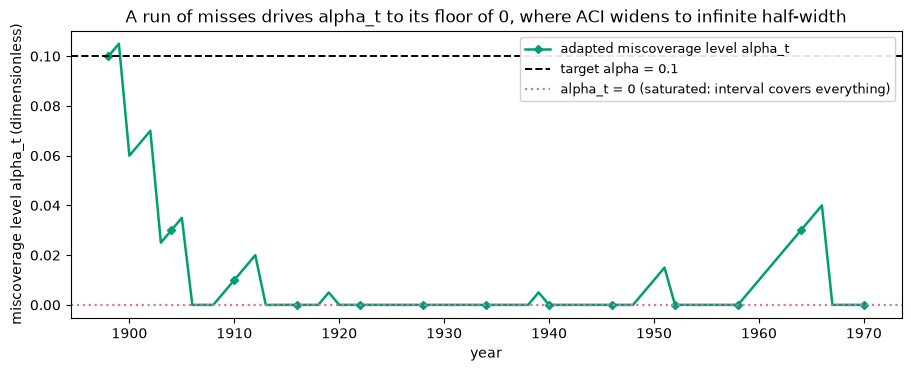

42 of 73 test steps had alpha_t = 0 (infinite half-width)


In [7]:
fig, ax = plt.subplots(figsize=(9, 3.6), constrained_layout=True)
ax.plot(
    test_year,
    aci_alpha,
    color="#009E73",
    lw=1.8,
    marker="D",
    markevery=6,
    ms=4,
    label="adapted miscoverage level alpha_t",
)
ax.axhline(ALPHA, color="black", ls="--", lw=1.4, label=f"target alpha = {ALPHA}")
ax.axhline(
    0.0,
    color="#CC79A7",
    ls=":",
    lw=1.6,
    label="alpha_t = 0 (saturated: interval covers everything)",
)
ax.set_xlabel("year")
ax.set_ylabel("miscoverage level alpha_t (dimensionless)")
ax.set_title(
    "A run of misses drives alpha_t to its floor of 0, where ACI widens to infinite half-width"
)
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
plt.show()

n_saturated = int(np.isinf(aci_hw).sum())
print(f"{n_saturated} of {aci_hw.size} test steps had alpha_t = 0 (infinite half-width)")

## ACI on a controlled shift, so we can see the recovery from the inside

The Nile is short and the break is brutal, so ACI mostly saturates. To watch the
controller in a regime where it stays in its working range, we build a synthetic series
with a milder shift: an AR(1) process whose noise scale triples and whose level jumps
at an index we choose. Since we set the break ourselves, the true coverage target is
known throughout.

In [8]:
rng = np.random.default_rng(7)
N = 800
BREAK = 400  # known shift location
PHI = 0.5

eps = rng.standard_normal(N)
base = np.zeros(N)
for t in range(1, N):
    base[t] = PHI * base[t - 1] + eps[t]

series = base.copy()
series[BREAK:] = series[BREAK:] * 3.0 + 6.0  # variance x3 and a +6 level jump

# Forecaster: trailing-mean over a short window. It adapts the LEVEL slowly but cannot
# keep up with the variance jump, so the residual scale shifts under it.
WINDOW = 20
pred = np.empty(N)
pred[0] = series[0]
for t in range(1, N):
    lo = max(0, t - WINDOW)
    pred[t] = series[lo:t].mean()
syn_scores = np.abs(series - pred)

# Calibration from a stable pre-break stretch; test starts before the break and crosses it.
TEST_START = 300
syn_cal = syn_scores[20:TEST_START]
syn_test = syn_scores[TEST_START:]
break_in_test = BREAK - TEST_START  # index of the break within the test sequence
print(
    "calibration size",
    syn_cal.size,
    "| test size",
    syn_test.size,
    "| break at test index",
    break_in_test,
)

calibration size 280 | test size 500 | break at test index 100


### Static versus ACI, split at the break

This is the central comparison: coverage of the static interval and the ACI interval,
each split into the pre-break and post-break halves of the test sequence.

In [9]:
import pandas as pd

syn_static_hw = float(np.quantile(syn_cal, 1.0 - ALPHA))
syn_static_cov = (syn_test <= syn_static_hw).astype(float)

syn_aci_hw, syn_aci_alpha = aci_halfwidths(syn_cal, syn_test, alpha=ALPHA, gamma=0.02)
syn_aci_cov = (syn_test <= syn_aci_hw).astype(float)

pre = slice(0, break_in_test)
post = slice(break_in_test, None)

split_coverage = pd.DataFrame(
    {
        "pre-break": [syn_static_cov[pre].mean(), syn_aci_cov[pre].mean()],
        "post-break": [syn_static_cov[post].mean(), syn_aci_cov[post].mean()],
        "overall": [syn_static_cov.mean(), syn_aci_cov.mean()],
    },
    index=["static interval", "ACI interval"],
).round(3)
print(f"target coverage = {NOMINAL:.2f}\n")
split_coverage

target coverage = 0.90



,pre-break,post-break,overall
static interval,0.91,0.388,0.492
ACI interval,0.89,0.890,0.890


Pre-break, both intervals sit near nominal: the calibration scores are representative,
so there is nothing to fix. Post-break the static interval collapses, because the
tripled noise scale makes the frozen quantile far too narrow. ACI widens step by step
and drags its post-break coverage back up toward the target. The overall ACI coverage
is close to nominal while the static one is not.

### The rolling picture and the half-widths

Two panels: rolling coverage (where the static interval visibly falls off the cliff at
the break) and the half-widths over time (where ACI visibly grows its interval to
absorb the larger residuals). For the half-width panel we cap the display, because ACI
briefly saturates to an infinite half-width right after the shock; the cap line marks
where that happens.

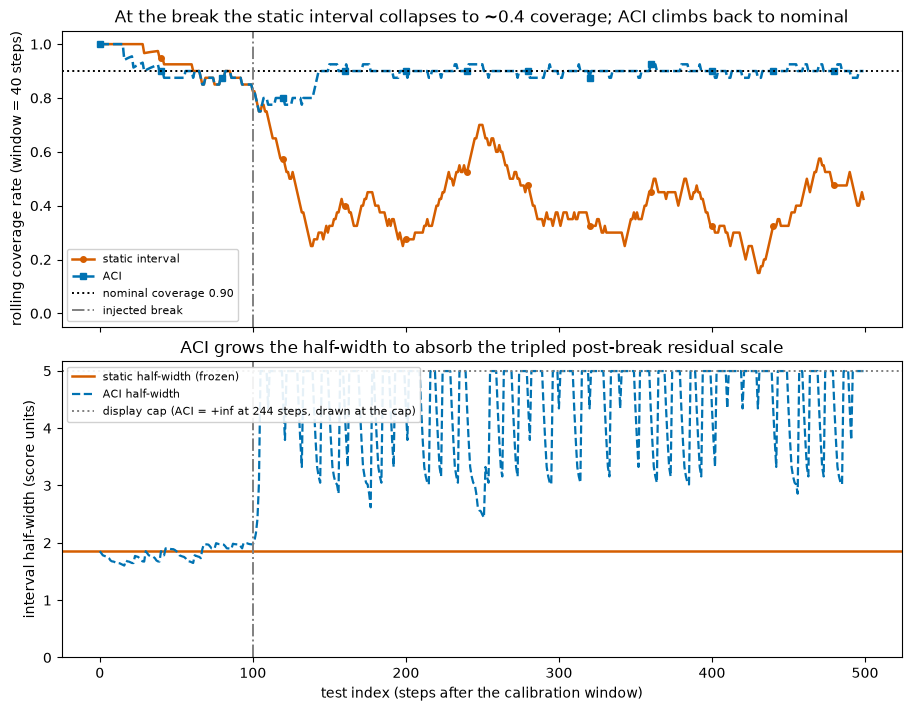

In [10]:
syn_static_roll = rolling_mean(syn_static_cov, 40)
syn_aci_roll = rolling_mean(syn_aci_cov, 40)
tt = np.arange(syn_test.size)

# Cap infinite ACI half-widths for display only.
finite = syn_aci_hw[np.isfinite(syn_aci_hw)]
cap = float(finite.max()) * 1.15
aci_hw_disp = np.where(np.isfinite(syn_aci_hw), syn_aci_hw, cap)
n_inf = int(np.isinf(syn_aci_hw).sum())

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(9, 7), sharex=True, constrained_layout=True)

# Top: rolling coverage.
ax0.plot(
    tt,
    syn_static_roll,
    color=C_STATIC,
    lw=1.8,
    ls="-",
    marker="o",
    markevery=40,
    ms=4,
    label="static interval",
)
ax0.plot(
    tt, syn_aci_roll, color=C_ACI, lw=1.8, ls="--", marker="s", markevery=40, ms=4, label="ACI"
)
ax0.axhline(NOMINAL, color="black", ls=":", lw=1.4, label=f"nominal coverage {NOMINAL:.2f}")
ax0.axvline(break_in_test, color="gray", ls="-.", lw=1.4, label="injected break")
ax0.set_ylim(-0.05, 1.05)
ax0.set_ylabel("rolling coverage rate (window = 40 steps)")
ax0.set_title(
    "At the break the static interval collapses to ~0.4 coverage; ACI climbs back to nominal"
)
ax0.legend(loc="lower left", fontsize=8, framealpha=0.9)

# Bottom: half-widths.
ax1.axhline(syn_static_hw, color=C_STATIC, lw=1.8, ls="-", label="static half-width (frozen)")
ax1.plot(tt, aci_hw_disp, color=C_ACI, lw=1.6, ls="--", label="ACI half-width")
ax1.axhline(
    cap,
    color="gray",
    ls=":",
    lw=1.4,
    label=f"display cap (ACI = +inf at {n_inf} steps, drawn at the cap)",
)
ax1.axvline(break_in_test, color="gray", ls="-.", lw=1.4)
ax1.set_ylim(bottom=0.0)
ax1.set_xlabel("test index (steps after the calibration window)")
ax1.set_ylabel("interval half-width (score units)")
ax1.set_title("ACI grows the half-width to absorb the tripled post-break residual scale")
ax1.legend(loc="upper left", fontsize=8, framealpha=0.9)
plt.show()

The top panel carries the argument: the red static-coverage line drops
at the dotted break and stays low, while the blue ACI line dips and then climbs back to
the dashed nominal line. The bottom panel shows why. The frozen red half-width never
moves, while ACI ramps its half-width up (briefly to infinity, the dotted cap) to cover
the bigger residuals, then settles at a wider but finite value matched to the new
regime.

## NexCP: reweighting calibration toward recent residuals

ACI adapts the target level. NexCP attacks the same problem from the other side: it
keeps the level fixed but reweights the calibration scores so recent residuals count
for more. That is the natural tool when the issue is a drifting scale or volatility
clustering rather than a single clean break.

We build a series that is calm for the first stretch and then ramps up in volatility,
the canonical drifting-scale setup. Then we deploy `nexcp_quantile` online: at each
step compute the recency-weighted quantile from all past scores and test it on the
next one. Sweeping the decay shows the trade.

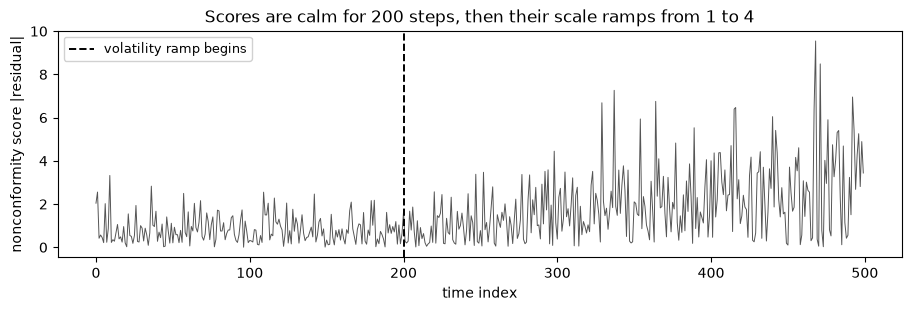

In [11]:
rng = np.random.default_rng(3)
M = 500
RAMP_START = 200
# Scale is flat, then ramps from 1 to 4: a slowly drifting / clustering volatility.
scale = np.concatenate(
    [
        np.full(RAMP_START, 1.0),
        np.linspace(1.0, 4.0, M - RAMP_START),
    ]
)
vol_scores = np.abs(rng.standard_normal(M) * scale)  # nonconformity scores

fig, ax = plt.subplots(figsize=(9, 3), constrained_layout=True)
ax.plot(vol_scores, color="#555555", lw=0.7)
ax.axvline(RAMP_START, color="black", ls="--", lw=1.4, label="volatility ramp begins")
ax.set_xlabel("time index")
ax.set_ylabel("nonconformity score |residual|")
ax.set_title("Scores are calm for 200 steps, then their scale ramps from 1 to 4")
ax.legend(fontsize=9, framealpha=0.9)
plt.show()

### A single snapshot: decay = 1 versus decay < 1

Before the online sweep, one snapshot makes the mechanism concrete. Compute the NexCP
quantile over the whole series for a few decay values, and compare to the empirical
90th percentile of the recent window. With `decay = 1` you get the ordinary quantile,
which averages in all the stale low-volatility scores and lands too low for the current
regime. Smaller decay tracks the recent window.

In [12]:
recent_q = float(np.quantile(vol_scores[-50:], 1.0 - ALPHA))
print(f"empirical 90th pct of the last 50 scores: {recent_q:.2f}\n")
for decay in (1.0, 0.99, 0.97, 0.95):
    q = nexcp_quantile(vol_scores, alpha=ALPHA, decay=decay)
    tag = "  (ordinary quantile)" if np.isclose(decay, 1.0) else ""
    print(f"decay = {decay:>4}: nexcp_quantile = {q:.2f}{tag}")

empirical 90th pct of the last 50 scores: 5.46

decay =  1.0: nexcp_quantile = 3.50  (ordinary quantile)
decay = 0.99: nexcp_quantile = 5.26
decay = 0.97: nexcp_quantile = 5.41
decay = 0.95: nexcp_quantile = 5.41


### Online coverage: ordinary quantile under-covers the new regime

Now the proper evaluation. Walk the series forward; at each step build the quantile
from the past and check whether it covers the next score. Split the resulting coverage
into the calm region and the ramp region. Decay = 1 should be fine in the calm region
and under-cover badly in the ramp; smaller decay should hold up in the ramp at the cost
of slightly wider, slightly over-covering intervals while calm.

In [13]:
WARM = 100  # need some history before the first quantile


def online_nexcp(decay):
    hits = np.empty(M - WARM)
    widths = np.empty(M - WARM)
    for j, t in enumerate(range(WARM, M)):
        q = nexcp_quantile(vol_scores[:t], alpha=ALPHA, decay=decay)
        hits[j] = vol_scores[t] <= q
        widths[j] = q
    return hits, widths


test_idx = np.arange(WARM, M)
calm_mask = test_idx < RAMP_START
ramp_mask = test_idx >= RAMP_START

online = {}
rows = []
for decay in (1.0, 0.99, 0.97, 0.95):
    hits, widths = online_nexcp(decay)
    online[decay] = (hits, widths)
    rows.append(
        {
            "decay": decay,
            "calm coverage": hits[calm_mask].mean(),
            "ramp coverage": hits[ramp_mask].mean(),
            "overall coverage": hits.mean(),
            "mean half-width": widths.mean(),
        }
    )

nexcp_table = pd.DataFrame(rows).set_index("decay").round(3)
print(f"target coverage = {NOMINAL:.2f}  (decay = 1.0 is the ordinary empirical quantile)\n")
nexcp_table

target coverage = 0.90  (decay = 1.0 is the ordinary empirical quantile)



,calm coverage,ramp coverage,overall coverage,mean half-width
decay,,,,
1.00,0.92,0.707,0.760,2.228
0.99,0.90,0.797,0.822,2.731
0.97,0.91,0.847,0.862,3.042
0.95,0.89,0.853,0.862,3.156


### The recency-weighting trade, plotted

Two panels again. Rolling coverage shows `decay = 1` sinking below nominal once the
ramp starts, while the recency-weighted curves stay closer to the target. The width
panel shows the cost: smaller decay produces wider intervals, which is how it
buys back the coverage in the volatile regime.

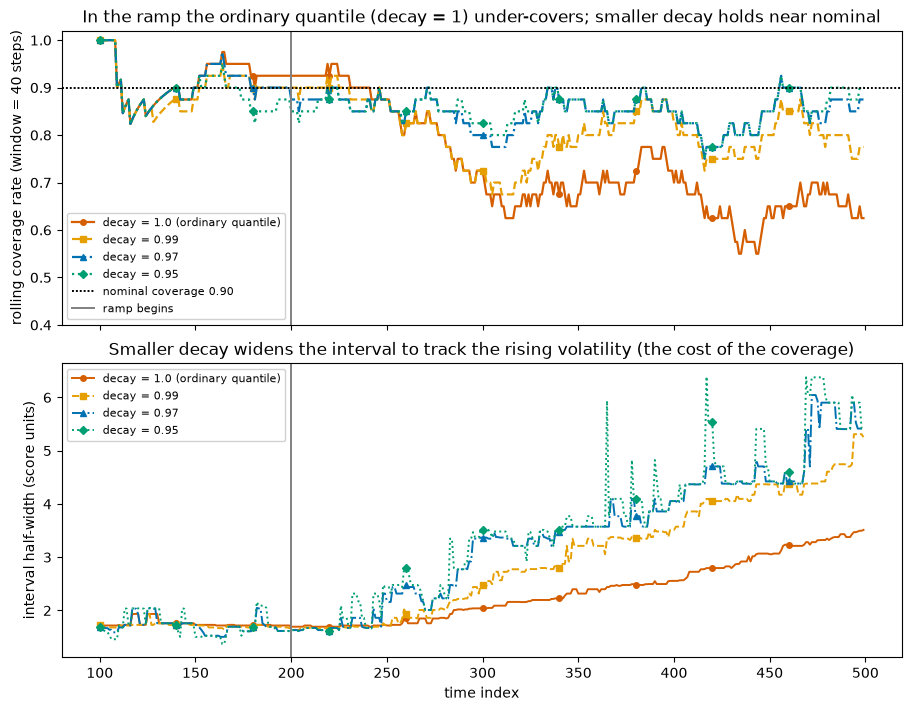

In [14]:
fig, (axc, axw) = plt.subplots(2, 1, figsize=(9, 7), sharex=True, constrained_layout=True)

# Colorblind-safe (Wong 2011) plus a distinct linestyle+marker per decay.
styles = {
    1.0: ("#D55E00", "-", "o"),  # ordinary quantile
    0.99: ("#E69F00", "--", "s"),
    0.97: ("#0072B2", "-.", "^"),
    0.95: ("#009E73", ":", "D"),
}

for decay, (hits, widths) in online.items():
    color, ls, mk = styles[decay]
    label = f"decay = {decay}" + (" (ordinary quantile)" if np.isclose(decay, 1.0) else "")
    axc.plot(
        test_idx,
        rolling_mean(hits, 40),
        color=color,
        ls=ls,
        marker=mk,
        markevery=40,
        ms=4,
        lw=1.6,
        label=label,
    )
    axw.plot(
        test_idx, widths, color=color, ls=ls, marker=mk, markevery=40, ms=4, lw=1.4, label=label
    )

axc.axhline(NOMINAL, color="black", ls=(0, (1, 1)), lw=1.4, label=f"nominal coverage {NOMINAL:.2f}")
axc.axvline(RAMP_START, color="gray", lw=1.4, label="ramp begins")
axc.set_ylim(0.4, 1.02)
axc.set_ylabel("rolling coverage rate (window = 40 steps)")
axc.set_title(
    "In the ramp the ordinary quantile (decay = 1) under-covers; smaller decay holds near nominal"
)
axc.legend(loc="lower left", fontsize=8, framealpha=0.9)

axw.axvline(RAMP_START, color="gray", lw=1.4)
axw.set_xlabel("time index")
axw.set_ylabel("interval half-width (score units)")
axw.set_title(
    "Smaller decay widens the interval to track the rising volatility (the cost of the coverage)"
)
axw.legend(loc="upper left", fontsize=8, framealpha=0.9)
plt.show()

The red `decay = 1` coverage line is the cautionary tale: a perfectly ordinary
conformal quantile, holding at nominal while calm, then sliding under the dashed line
as the volatility climbs because it keeps averaging in stale calm-period residuals.
The recency-weighted lines stay nearer the target, and the width panel shows they do it
the only way they can, by widening as the recent residuals grow.

## When to reach for which

- **`aci_halfwidths` (ACI)** when you want a long-run coverage guarantee that survives
  arbitrary, possibly abrupt shift, and you can tolerate that any single interval may be
  off and that a hard shock can briefly blow the interval up to infinite width while the
  level controller catches up. Tune `gamma`: larger reacts faster but jitters more.
- **`nexcp_quantile` (NexCP)** when the drift is smooth, like a changing scale or
  volatility clustering, and you want a finite-sample-flavoured guarantee with intervals
  that follow the recent regime. Tune `decay`: smaller leans harder on recent residuals.
- **Sliding-window EnbPI** (the forecast-intervals tutorial) when you would rather
  refresh the residuals from a moving window than touch the level or the weights.

All three operate on the same input, per-step nonconformity scores, which is what the
bootstrap layer produces via the out-of-bag residuals. The bootstrap manufactures the
scores, and these small adaptive functions turn a drifting stream of scores into an
interval that holds its target coverage.